In [1]:
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

ml_client = MLClient.from_config(credential=DefaultAzureCredential())
print(f"Connected to Workspace: {ml_client.workspace_name}")

Found the config file in: /config.json


Connected to Workspace: fraud_detection_project


In [2]:
import pandas as pd

# Helper function to make loading faster
def load_azure_csv(asset_name):
    asset = ml_client.data.get(name=asset_name, version="1")
    return pd.read_csv(asset.path)

# Load Features
X_train_imb = load_azure_csv("X-train-imb")
X_train_smote = load_azure_csv("X-train-smote")
X_test = load_azure_csv("X-test-final")

# Load Labels (and flatten to 1D array)
y_train_imb = load_azure_csv("y-train-imb").values.ravel()
y_train_smote = load_azure_csv("y-train-smote").values.ravel()
y_test = load_azure_csv("y-test-final").values.ravel()

print("All cloud assets loaded successfully!")

Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/mlflow/__init__.py:41: UserWarning: Versions of mlflow (2.7.1) and child packages mlflow-skinny (3.9.0), mlflow-tracing (3.8.1) are different. This may lead to unexpected behavior. Please install the same version of all MLflow packages.
  mlflow.mismatch._check_version_mismatch()
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook 

All cloud assets loaded successfully!


In [3]:
import mlflow

# Point MLflow to Azure ML Workspace
mlflow.set_tracking_uri(ml_client.workspaces.get(ml_client.workspace_name).mlflow_tracking_uri)

# Set the Experiment Name
experiment_name = "fraud-detection-tournament"
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='', creation_time=1771958099637, experiment_id='6154cf18-a565-4006-88ec-6e5e4b3c9edc', last_update_time=None, lifecycle_stage='active', name='fraud-detection-tournament', tags={}>

In [10]:
import mlflow
from sklearn.metrics import average_precision_score, recall_score, precision_score, f1_score

mlflow.sklearn.autolog(disable=True)

for scenario_name, (train_x, train_y) in scenarios.items():
    for model_name, model in models.items():
        
        with mlflow.start_run(run_name=f"{model_name}-{scenario_name}"):
            
            print(f"🚀 Training {model_name} on {scenario_name}...", flush=True)
            
            # --- TRAIN ---
            model.fit(train_x, train_y)
            
            # --- PREDICT ---
            probs = model.predict_proba(X_test)[:, 1]
            preds = model.predict(X_test)
            
            # --- CALCULATE METRICS ---
            auprc = average_precision_score(y_test, probs)
            recall = recall_score(y_test, preds)
            precision = precision_score(y_test, preds)
            f1 = f1_score(y_test, preds)
            
            # --- LOG PARAMETERS ---
            mlflow.log_param("Algorithm", model_name)
            mlflow.log_param("Data Strategy", scenario_name)
            
            # --- LOG METRICS ---
            mlflow.log_metric("AUPRC", auprc)
            mlflow.log_metric("Recall", recall)
            mlflow.log_metric("Precision", precision)
            mlflow.log_metric("F1-Score", f1)
            
            print(f"Metrics logged: AUPRC={auprc:.4f}, Recall={recall:.4f}", flush=True)

print("\n--- Tournament Complete! Check the 'Jobs' tab in Azure ML Studio to compare results. ---")

🚀 Training Logistic_Regression on Imbalanced...
Metrics logged: AUPRC=0.7353, Recall=0.6531
🏃 View run Logistic_Regression-Imbalanced at: https://uksouth.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/uctzyac-rg/providers/Microsoft.MachineLearningServices/workspaces/fraud_detection_project/#/experiments/6154cf18-a565-4006-88ec-6e5e4b3c9edc/runs/22bcbf78-bd13-403c-943f-05af9994aa71
🧪 View experiment at: https://uksouth.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/uctzyac-rg/providers/Microsoft.MachineLearningServices/workspaces/fraud_detection_project/#/experiments/6154cf18-a565-4006-88ec-6e5e4b3c9edc
🚀 Training Random_Forest on Imbalanced...
Metrics logged: AUPRC=0.8675, Recall=0.8265
🏃 View run Random_Forest-Imbalanced at: https://uksouth.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/uctzyac-rg/providers/Microsoft.MachineLearningServices/workspac

In [57]:
# 1. Get the Experiment ID by name
experiment = mlflow.get_experiment_by_name("fraud-detection-tournament")

# 2. Search for all runs in this experiment
# This returns a pandas DataFrame automatically!
runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

# 3. Clean up the view (Optional)
# MLflow adds many columns (start time, tags, etc.); let's pick the important ones
cols_to_keep = [
    'run_id',
    'params.Algorithm', 
    'params.Data Strategy', 
    'metrics.AUPRC', 
    'metrics.Recall', 
    'metrics.Precision', 
    'metrics.F1-Score'
]

summary_df = runs_df[cols_to_keep].copy()

# Rename columns for a cleaner look
summary_df.columns = ['run_id','Algorithm', 'Data Strategy', 'AUPRC', 'Recall', 'Precision', 'F1-Score']


# Rank by AUPRC descending
ranked_models = summary_df.dropna(subset=['Algorithm']).drop_duplicates().sort_values(by='AUPRC', ascending=False).reset_index(drop=True)

# Display the final leaderboard
display(ranked_models)

,run_id,Algorithm,Data Strategy,AUPRC,Recall,Precision,F1-Score
0,14bf20e2-c104-4f54-a571-5ed8e946ce87,Random_Forest,SMOTE,0.880709,0.826531,0.880435,0.852632
1,5a4c7525-5375-47d2-b01a-5abcefcf7d7a,XGBoost,SMOTE,0.871347,0.867347,0.708333,0.779817
2,896becb9-2563-4ccd-becb-c2e307017361,Random_Forest,Imbalanced,0.867538,0.826531,0.952941,0.885246
3,73362a61-24e6-4249-bab3-95e8a842bfa2,XGBoost,Imbalanced,0.804338,0.785714,0.885057,0.832432
4,17fb1b01-ff14-4e41-b8e1-ca3bdf670b4f,Logistic_Regression,Imbalanced,0.735294,0.653061,0.790123,0.715084
5,aa4b4c25-77a5-4b46-91e3-5a0f921e57bc,Logistic_Regression,Imbalanced,0.735294,0.653061,0.790123,0.715084
6,22bcbf78-bd13-403c-943f-05af9994aa71,Logistic_Regression,Imbalanced,0.735294,0.653061,0.790123,0.715084
7,4654a448-f783-4b3d-8f38-1401d8e5b359,Logistic_Regression,SMOTE,0.727711,0.918367,0.054979,0.103746


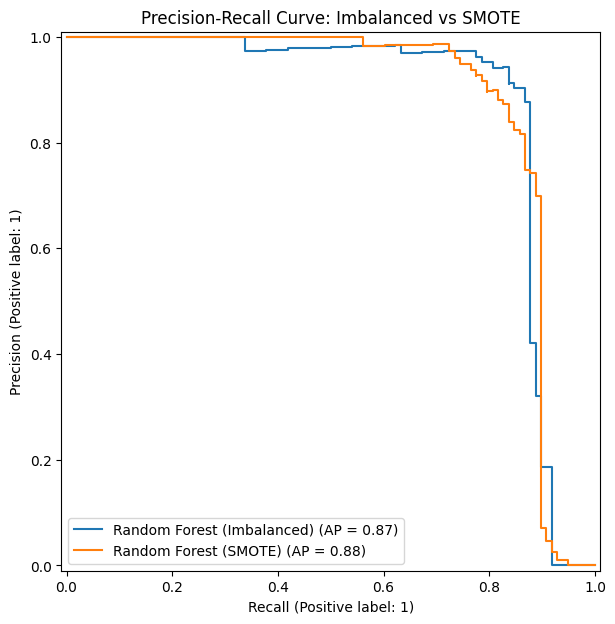

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(10, 7))

# Plot the random forest for both to see the SMOTE impact clearly
for scenario_name, (train_x, train_y) in scenarios.items():
    model = RandomForestClassifier().fit(train_x, train_y)
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax, name=f"Random Forest ({scenario_name})")

plt.title("Precision-Recall Curve: Imbalanced vs SMOTE")
plt.show()

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

mlflow.set_experiment("RF-finetuning")
mlflow.sklearn.autolog(max_tuning_runs=15, log_models=True)

# Create a pipeline: SMOTE -> Classifier
# This ensures SMOTE only happens on training folds, never on validation
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

# Update your param_dist to include the 'rf__' prefix
param_dist_fast = {
    'rf__n_estimators': [100, 150], 
    'rf__max_depth': [10, 15],
    'rf__min_samples_leaf': [4, 8]
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=5,
    cv=2,
    scoring='average_precision', # Keep this!
    n_jobs=-1,
    verbose=3
)

# Use the ORIGINAL training data
random_search.fit(X_train_imb, y_train_imb)

print(f"✅ Best AUPRC Found: {random_search.best_score_:.4f}")
print(f"🏆 Best Params: {random_search.best_params_}")

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Replace 'best_model' with the one that had the highest AUPRC in your results_df
best_model = models["Random Forest"].fit(X_train_imb, y_train_imb) 
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Best Performing Model")
plt.show()

In [ ]:
mlflow.set_experiment("RF-finetuning")
mlflow.sklearn.autolog(max_tuning_runs=15, log_models=True)

mlflow.sklearn.autolog(disable=True)

# 1. Use a slightly larger sample for better signal (50,000 rows)
X_smote_sample = X_train_smote[:50000]
y_smote_sample = y_train_smote[:50000]

# 2. Expanded Search Space
param_dist = {
    'n_estimators': [100, 200, 400],           # More trees = more stability
    'max_depth': [10, 20, 30, None],          # Let it explore deeper trees
    'min_samples_leaf': [1, 2, 4, 8],         # Control overfitting
    'max_features': ['sqrt', 'log2', None]    # How many features per split
}

# 3. Higher Intensity Search
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=15,          # Try 15 different recipes (instead of 1-5)
    cv=3,               # 3-fold cross-validation for more reliable scores
    scoring='average_precision', 
    verbose=2,
    n_jobs=-1           # Use both cores
)

print("Starting the fine tuning...")
random_search.fit(X_smote_sample, y_smote_sample)

print(f"✅ Best AUPRC Found: {random_search.best_score_:.4f}")
print(f"🏆 Best Params: {random_search.best_params_}")

In [ ]:
mlflow.set_experiment("RF-finetuning")
mlflow.sklearn.autolog(max_tuning_runs=15, log_models=True)

mlflow.sklearn.autolog(disable=True)

# Use a representative sample to speed up the fine tunring
X_smote_sample = X_train_smote[:30000]
y_smote_sample = y_train_smote[:30000]

# define search space
param_dist = {
    'n_estimators': [50, 100], 
    'max_depth': [10, 15], 
    'min_samples_leaf': [2, 5]
}

# Optimized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=3,        # 3 combinations
    cv=2,            # 2-fold cross-validation
    scoring='average_precision', 
    verbose=2,
    n_jobs=-1        # Uses both of your cores
)

random_search.fit(X_smote_sample, y_smote_sample)

model_filename = "tuned_rf_champion.pkl"
with open(model_filename, "wb") as f:
    pickle.dump(random_search.best_estimator_, f)

# 2. Upload it to Azure as an 'Artifact'
# We use a fresh run to keep things clean
with mlflow.start_run(run_name="RF_Tuning"):
    # Log the parameters so you have them for your CV
    mlflow.log_params(random_search.best_params_)
    
    # Upload the actual file into a folder called 'model_package'
    mlflow.log_artifact(model_filename, artifact_path="model_package")
    
    print("SUCCESS: Tuned model saved and uploaded to Azure!")
    print(f"Best Parameters: {random_search.best_params_}")
    

In [ ]:
from sklearn.metrics import average_precision_score

# 1. Predict with the Tuned Model
y_probs_tuned = random_search.best_estimator_.predict_proba(X_test)[:, 1]
tuned_auprc = average_precision_score(y_test, y_probs_tuned)

# 2. Predict with your previous Best Model (The 0.8807 one)
# (Assuming 'best_model' from the previous step is still in memory)
# If not, we'll just compare against the hardcoded 0.8807
improvement = ((tuned_auprc - 0.8807) / 0.8807) * 100

print(f"🏁 Final Results:")
print(f"Original AUPRC: 0.8807")
print(f"Tuned AUPRC:    {tuned_auprc:.4f}")
print(f"Performance Lift: {improvement:.2f}%")

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

# Create a single plot comparing both models
fig, ax = plt.subplots(figsize=(10, 6))

best_run_id = ranked_models.loc[0, 'run_id']
best_model_uri = f"runs:/{best_run_id}/model_package"
best_model = mlflow.sklearn.load_model(best_model_uri)

# Plot Baseline (your 0.8807 model)
PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=ax, name="Baseline RF")

# Plot Tuned (the one you just finished)
PrecisionRecallDisplay.from_estimator(random_search.best_estimator_, X_test, y_test, ax=ax, name="Tuned Champion")

plt.title("The 'Money' Chart: Precision-Recall Improvement")
plt.legend()
plt.show()

In [ ]:
mlflow.set_experiment("fraud-detection-tuning")
mlflow.sklearn.autolog(max_tuning_runs=10, log_models=True)

from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# 1. Define the Parameter Space
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)

# Use 'average_precision' (AUPRC) as the scorer for imbalanced data
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=5,             # 5 combinations to keep it fast; increase for better results
    scoring='average_precision', 
    cv=3,                 # 3-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 3. Fit with MLflow tracking
# Wrap in a parent run to keep the 'Tournament' organized
with mlflow.start_run(run_name="RandomForest-SMOTE-Tuned") as parent_run:
    print("Fine-tuning in progress...")
    random_search.fit(X_train_smote, y_train_smote)
    
    # Evaluate on the final test set
    best_rf = random_search.best_estimator_
    mlflow.log_params(random_search.best_params_)

    # Log the improved metric
    best_score = random_search.best_score_
    mlflow.log_metric("Best_CV_AUPRC", best_score)
    
    # Save the final tuned model
    mlflow.sklearn.log_model(best_tuned_model, artifact_path="model_package")
    
    print(f"\nTuning Complete!")
    print(f"Best AUPRC: {best_score:.4f}")
    print(f"Best Params: {random_search.best_params_}")

In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# 1. Prepare the winning Data Strategy
print("🔄 Preparing SMOTE data for tuning...")
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# 2. Define the search space
# We tune 'min_samples_leaf' and 'max_depth' to prevent SMOTE overfitting
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# 3. Setup the Champion Search
rf = RandomForestClassifier(random_state=42)

# We optimize for 'average_precision' (AUPRC) as it was our tournament metric
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=5,             # 5 combinations to keep it fast; increase for better results
    scoring='average_precision', 
    cv=3,                 # 3-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 4. Run the Tune inside an MLflow Parent Run
with mlflow.start_run(run_name="CHAMPION_FINE_TUNING") as parent_run:
    
    print("🚀 Starting Hyperparameter Sweep...")
    random_search.fit(X_res, y_res)
    
    # Get the best version
    best_tuned_model = random_search.best_estimator_
    
    # Log the best parameters
    mlflow.log_params(random_search.best_params_)
    
    # Log the improved metric
    best_score = random_search.best_score_
    mlflow.log_metric("Best_CV_AUPRC", best_score)
    
    # Save the final tuned model
    mlflow.sklearn.log_model(best_tuned_model, artifact_path="model_package")
    
    print(f"\n✨ Tuning Complete!")
    print(f"Best AUPRC: {best_score:.4f}")
    print(f"Best Params: {random_search.best_params_}")

In [ ]:
# 1. Fetch the data from MLflow
# We search both experiments where we logged our results
experiment_names = ["fraud-detection-tournament", "fraud-detection-tuning"]
runs_df = mlflow.search_runs(experiment_names=experiment_names)

# 2. Extract our two competitors
# Baseline: The best RF from the first loop
baseline_mask = (runs_df['tags.mlflow.runName'].str.contains("Random Forest-SMOTE", na=False))
# Tuned: The result from our recent Parent run
tuned_mask = (runs_df['tags.mlflow.runName'] == "RF-SMOTE-Tuned-Parent")

# 3. Create a comparison table
comparison_results = []

for mask, label in [(baseline_mask, "Baseline RF (SMOTE)"), (tuned_mask, "Fine-Tuned RF (SMOTE)")]:
    run = runs_df[mask].iloc[0]
    # Check if we have AUPRC or final_test_AUPRC (depending on which tag you used)
    auprc = run.get('metrics.AUPRC') if pd.notnull(run.get('metrics.AUPRC')) else run.get('metrics.final_test_AUPRC')
    recall = run.get('metrics.Recall')
    
    comparison_results.append({
        "Model Version": label,
        "AUPRC (Precision-Recall)": auprc,
        "Recall": recall,
        "Run ID": run['run_id']
    })

final_comparison_df = pd.DataFrame(comparison_results)

# 4. Display results and determine the Winner
display(final_comparison_df)

# Automatic logic to pick the winner
best_idx = final_comparison_df['AUPRC (Precision-Recall)'].idxmax()
winner_name = final_comparison_df.loc[best_idx, 'Model Version']
lift = (final_comparison_df.loc[1, 'AUPRC (Precision-Recall)'] - final_comparison_df.loc[0, 'AUPRC (Precision-Recall)']) / final_comparison_df.loc[0, 'AUPRC (Precision-Recall)']

print("-" * 30)
print(f"THE WINNER: {winner_name}")
print(f"Performance Lift: {lift:.2%}")
print("-" * 30)

In [ ]:
import joblib
import os

# Create a folder for the model artifacts
model_path = "../models"
os.makedirs(model_path, exist_ok=True)

# Save the winning model (Random Forest + SMOTE)
joblib.dump(value=final_model, filename=f"{model_path}/fraud_rf_model.pkl")

print(f"Model saved locally at {model_path}/fraud_rf_model.pkl")

In [ ]:
from azure.ai.ml.entities import Model
from azure.ai.ml.constants import AssetTypes

# 1. Define the model metadata
file_model = Model(
    path=f"{model_path}/fraud_rf_model.pkl",
    type=AssetTypes.CUSTOM_MODEL,
    name="fraud-detection-rf-smote",
    description="Random Forest model trained on SMOTE-balanced credit card data.",
    version="1"
)

# 2. Register the model in the Workspace
registered_model = ml_client.models.create_or_update(file_model)

print(f"Model registered successfully!")
print(f"Name: {registered_model.name}")
print(f"Version: {registered_model.version}")